# Chapter 2: Data Processing and Analysis
In this chapter we conduct preliminary exploration and analysis of the Goodreads dataset. The primary focus of this analysis is examining the distribution of the underlying data, and reviewing basic descriptive statistics for user-book interactions.

A secondary focus of this chapter is memory management, due to the size of the source files. Only necessary fields are loaded into pandas, memory-efficient datatypes are selected, and unused columns and dataframes are deleted after use. 

Many of the steps in preprocessing the dataset overlap with this exploration: This chapter conducts both concurrently. 

The *load_ratings()* method is available in wrecksys_ai.io, which performs the preprocessing without Jupyter. 

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wrecksys_ai.config import ConfigFile
from wrecksys_ai.io import download_source_data

In [2]:
CONFIG = ConfigFile()
fm = download_source_data()
list(fm.keys())

['authors', 'books', 'ratings', 'reviews', 'works']

## Books

The books file contains metadata for each of the titles in the Fantasy & Paranormal dataset. It contains a wealth of information for engineering features and generating embeddings. Wrecksys uses none of it: Partly because it's a sequential recommendation system, but mostly because it's not very good. But hey, it works!  

The example books record in the previous chapter revealed four fields with nested data types: *series*, *popular_shelves*, *similar_books*, and *authors.*
- We are stubbornly ignoring *similar_books* for obvious reasons.  

The books file references authors by author_id, which makes processing *authors* necessary. The other three fields won't be used, and the arbitrarily deep nesting in *popular_shelves* is a source of concern. We'll skip loading those from the start.

In [3]:
no_thanks = ['series', 'popular_shelves', 'similar_books']
book_columns = [k for k in fm['books'].example.keys() if k not in no_thanks]
book_list = fm['books'].dataframe(cols=book_columns)
book_list.shape

(258585, 26)

In [4]:
book_list.head()

,isbn,text_reviews_count,country_code,language_code,asin,is_ebook,average_rating,kindle_asin,description,format,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,7,US,eng,B00071IKUY,false,4.03,,Omnibus book club edition containing the Ladie...,Hardcover,...,,Book Club Edition,1987,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...,7327624,140,8948723,"The Unschooled Wizard (Sun Wolf and Starhawk, ...","The Unschooled Wizard (Sun Wolf and Starhawk, ..."
1,1934876569,6,US,,,false,4.22,,"To Kara's astonishment, she discovers that a p...",Paperback,...,3,,2009,https://www.goodreads.com/book/show/6066812-al...,https://images.gr-assets.com/books/1316637798m...,6066812,98,701117,All's Fairy in Love and War (Avalon: Web of Ma...,All's Fairy in Love and War (Avalon: Web of Ma...
2,,60,US,eng,B01NCIKAQX,true,4.33,B01NCIKAQX,,,...,,,,https://www.goodreads.com/book/show/33394837-t...,https://images.gr-assets.com/books/1493114742m...,33394837,269,54143148,The House of Memory (Pluto's Snitch #2),The House of Memory (Pluto's Snitch #2)
3,,1,US,,B0056A00P4,true,4.04,B0056A00P4,This is the final tale in the bestselling auth...,,...,,,,https://www.goodreads.com/book/show/12182387-t...,https://s.gr-assets.com/assets/nophoto/book/11...,12182387,4,285263,"The Passion (Dark Visions, #3)","The Passion (Dark Visions, #3)"
4,,21,US,en-US,B01BLJGA9S,true,4.23,B01BLJGA9S,,,...,,,,https://www.goodreads.com/book/show/29074693-p...,https://s.gr-assets.com/assets/nophoto/book/11...,29074693,149,46079519,"Prowled Darkness (Dante's Circle, #7)","Prowled Darkness (Dante's Circle, #7)"


In [5]:
book_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258585 entries, 0 to 258584
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   isbn                  258585 non-null  object
 1   text_reviews_count    258585 non-null  object
 2   country_code          258585 non-null  object
 3   language_code         258585 non-null  object
 4   asin                  258585 non-null  object
 5   is_ebook              258585 non-null  object
 6   average_rating        258585 non-null  object
 7   kindle_asin           258585 non-null  object
 8   description           258585 non-null  object
 9   format                258585 non-null  object
 10  link                  258585 non-null  object
 11  authors               258585 non-null  object
 12  publisher             258585 non-null  object
 13  num_pages             258585 non-null  object
 14  publication_day       258585 non-null  object
 15  isbn13           

Pandas reports no null values in the book list, but empty columns are clearly visible in the first 5 rows. An empty string is currently considered a value, which we need to correct. But first we need to process 'authors'

The values in the authors column are either a list of dicts, or empty strings.
Cleaning up the column will be a three-step process:
1) If the cell contains a list, map it to the first element in the list, or else map it to None.
2) Map the resulting dicts to the first 'author_id' value.
3) Cast the resulting elements to integers.

In [6]:
book_list['authors'] = (
    book_list['authors']
    .map(lambda x: x[0] if len(x) > 0 else pd.NA, na_action='ignore')
    .map(lambda x: x['author_id'] if isinstance(x, dict) else x, na_action='ignore')
    .astype('Int64')
)
book_list.rename(columns={'authors': 'author_id'}, inplace=True)

book_list.author_id.head()

0      10333
1      19158
2     242185
3      50873
4    5360266
Name: author_id, dtype: Int64

In [7]:
# Now that we've reduced authors to a single value, we can use replace on the dataframe.
# All empty strings are converted to null values.
book_list.replace('', pd.NA, inplace=True)
book_list.isna().sum()

isbn                    129547
text_reviews_count           0
country_code                 0
language_code            70664
asin                    187675
is_ebook                     0
average_rating               0
kindle_asin             133761
description              20704
format                   68678
link                         0
author_id                    2
publisher                73031
num_pages                82241
publication_day          98086
isbn13                  100710
publication_month        82141
edition_information     231790
publication_year         62511
url                          0
image_url                    0
book_id                      0
ratings_count                0
work_id                      0
title                        0
title_without_series         0
dtype: int64

In a perfect world, we would keep either the ISBN or ASIN to leverage the Google Books and Amazon APIs. Sadly, over half the books are missing identifiers, and it's beyond the scope of this project to fix.

Of the remaining columns, a few are of particular interest:

- ***title, url, image_url, link*** These will be helpful, since GoodReads no longer provides an API and the lack of complete ASIN/ISBN 
information makes using other sources challenging.  We'll retain these for use in the user interface.
- ***author_id, book_id, work_id*** These will be used to join on the other dataframes.
- ***ratings_count, average_rating*** While interesting, the data set contains multiple sources for these metrics. 
We ignore these in favor of the ratings data for each individual work.

In [8]:
book_columns = ['title', 'url', 'image_url', 'link', 'author_id', 'book_id', 'work_id']
book_list = book_list[book_columns]
book_list.isna().sum()

title        0
url          0
image_url    0
link         0
author_id    2
book_id      0
work_id      0
dtype: int64

In [9]:
# Two books with null authors?
book_list[book_list['author_id'].isna()]

,title,url,image_url,link,author_id,book_id,work_id
72992,The Werewolf of Plonkert,https://www.goodreads.com/book/show/7520314-th...,https://s.gr-assets.com/assets/nophoto/book/11...,https://www.goodreads.com/book/show/7520314-th...,<NA>,7520314,1025915
211618,The Best Ghost Stories,https://www.goodreads.com/book/show/11696786-t...,https://s.gr-assets.com/assets/nophoto/book/11...,https://www.goodreads.com/book/show/11696786-t...,<NA>,11696786,6450316


In [10]:
# Fortunately we have plenty of books
book_list = book_list[~book_list['author_id'].isna()]

# Convert all remaining records to appropriate data types.
book_list = book_list.astype({
            'title': 'string',
            'url': 'string',
            'image_url': 'string',
            'link': 'string',
            'book_id': 'Int64',
            'work_id': 'Int64'})
book_list.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258583 entries, 0 to 258584
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   title      258583 non-null  string
 1   url        258583 non-null  string
 2   image_url  258583 non-null  string
 3   link       258583 non-null  string
 4   author_id  258583 non-null  Int64 
 5   book_id    258583 non-null  Int64 
 6   work_id    258583 non-null  Int64 
dtypes: Int64(3), string(4)
memory usage: 16.5 MB


## Authors

The authors file doesn't contain much information of interest. *rating_count* and *average_rating* could potentially be used in creating author embeddings, but Wrecksys doesn't use them. The only information we need from the authors file are the *name* and *author_id*.  

In [11]:
author_list = (
    fm['authors']
    .dataframe(cols=['author_id', 'name'])
    .astype({'author_id': 'Int64', 'name': 'string'})
    .rename(columns={'name': 'author_name'})
)
author_list.head()

,author_id,author_name
0,604031,Ronald J. Fields
1,626222,Anita Diamant
2,10333,Barbara Hambly
3,9212,Jennifer Weiner
4,149918,Nigel Pennick


In [12]:
# That's it for authors until it's time to build the derivative data product.
# It's worth noting again that the author information is from the complete 
# dataset, not just the Fantasy & Paranormal subset.
author_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829529 entries, 0 to 829528
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   author_id    829529 non-null  Int64 
 1   author_name  829529 non-null  string
dtypes: Int64(1), string(1)
memory usage: 13.4 MB


## Works

Goodreads combines different editions of the same book into "works," which can be treated as a single unit. Different editions such as hardcover, paperback, kindle, etc. will all have different ISBNs. All the various identifiers still refer to the same piece of fiction. Work IDs consolidate multiple formats and printings into one item. Wrecksys is built on Work IDs.

The wrecksys model bases its recommendations on works, rather than books, to avoid recommending multiple editions of the same book. A user who enjoyed *The Hobbit* is likely to also enjoy the 75th anniversary edition. That same user is unlikely to deem that recommendation useful.

From the available data, there are 4 fields to extract:
- ***work_id*** as the primary key.
- ***best_book_id*** when combined with the work_id will allow us to match each work with the metadata of its best example.
- ***ratings_count*** as a proxy for the popularity of a given work.
- ***ratings_sum*** combined with ratings_count will allow us to calculate the average rating of each work.    

In [13]:
work_list = (
    fm['works']
    .dataframe(cols=['work_id', 'best_book_id', 'ratings_count', 'ratings_sum'])
    .astype('Int64')
    .rename(columns={'best_book_id': 'book_id'})
)
work_list['average_rating'] = round(work_list['ratings_sum'] / work_list['ratings_count'], 1)
work_list.head()

,work_id,book_id,ratings_count,ratings_sum,average_rating
0,5400751,5333265,3,12,4.0
1,1323437,25717,6229,20150,3.2
2,8948723,7327624,141,568,4.0
3,6243154,6066819,53273,185670,3.5
4,278577,287140,15,51,3.4


In [14]:
# The works data, just like the author data, is based on the entire Goodreads Dataset.
# We'll eliminate extraneous rows when we assemble the final product.
work_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1521962 entries, 0 to 1521961
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   work_id         1521962 non-null  Int64  
 1   book_id         1521962 non-null  Int64  
 2   ratings_count   1521962 non-null  Int64  
 3   ratings_sum     1521962 non-null  Int64  
 4   average_rating  1521962 non-null  Float64
dtypes: Float64(1), Int64(4)
memory usage: 65.3 MB


## Reviews

The reviews file offers a rich source of contextual information for generating embeddings for both books and users. Natural Language Processing is out of scope for this project, so this file is currently ignored.

## Ratings

The interactions file contains 55 million records of interactions between Goodreads users and books. An interaction, in this context, is one of the following actions: 
- Adding a book to a shelf. 
- Marking a book as read.
- Rating a book. 
- Reviewing a book.

In order to avoid excessive swapping to disk, only necessary columns are loaded. These are:

- ***user_id*** Who rated a book? 
- ***book_id*** Which book?
- ***rating*** Did they rate it? What did they think?
- ***date_updated*** provides the date and time of the most recent interaction. A timestamp is a necessary component of a sequential recommendation algorithm. This dataset offers four choices of timestamp: *date_added*, *date_updated*, *read_at*, and *started_at*. Of the four, date_updated is the best suited for our purposes.
- ***is_read*** and ***review_text_incomplete*** provide additional details about the type of interaction. These columns are included to assist analysis. 

If you are running the code in this notebook yourself, you have my apologies for how long some of the cells in the next section are going to take.

In [15]:
rating_columns = ['user_id', 'book_id', 'rating', 'date_updated', 'is_read', 'review_text_incomplete']
rating_list = fm['ratings'].dataframe(cols=rating_columns)
print(rating_list.shape)

(55397550, 6)


In [16]:
rating_list.head()

,user_id,book_id,rating,date_updated,is_read,review_text_incomplete
0,8842281e1d1347389f2ab93d60773d4d,19161852,0,Fri Sep 08 10:44:24 -0700 2017,False,
1,8842281e1d1347389f2ab93d60773d4d,18245960,5,Wed Aug 30 00:00:26 -0700 2017,True,This is a special book. It started slow for ab...
2,8842281e1d1347389f2ab93d60773d4d,32075825,0,Wed May 31 06:41:51 -0700 2017,False,
3,8842281e1d1347389f2ab93d60773d4d,43615,0,Mon Apr 03 13:27:30 -0700 2017,False,
4,8842281e1d1347389f2ab93d60773d4d,26721984,0,Wed Mar 29 00:28:31 -0700 2017,False,


In [17]:
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55397550 entries, 0 to 55397549
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   user_id                 object
 1   book_id                 object
 2   rating                  int64 
 3   date_updated            object
 4   is_read                 bool  
 5   review_text_incomplete  object
dtypes: bool(1), int64(1), object(4)
memory usage: 2.1+ GB


In [18]:
rating_list.isnull().sum()

user_id                   0
book_id                   0
rating                    0
date_updated              0
is_read                   0
review_text_incomplete    0
dtype: int64

The interactions table suffers from the same problem as the books table: Empty strings are still counted as values, but we'll address that while cleaning up our dtypes.

In [19]:
not_strings = {'book_id': 'Int64', 'is_read': 'bool', 'rating': 'Int64'}

for col in rating_list.columns:
    dtype = not_strings.get(col, 'string')
    rating_list[col] = rating_list[col].astype(dtype)

rating_list.dtypes

user_id                   string[python]
book_id                            Int64
rating                             Int64
date_updated              string[python]
is_read                             bool
review_text_incomplete    string[python]
dtype: object

In [20]:
# review_text_incomplete is included to distinguish the type of interaction.
# Knowing that a user wrote a review is sufficient for our analysis, the actual
# text can be discarded.
rating_list['review_text_incomplete'] = rating_list['review_text_incomplete'].map(lambda r: len(r) > 0).astype('bool')
rating_list.rename(columns={'review_text_incomplete': 'is_reviewed'}, inplace=True)
rating_list.info()                                         

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55397550 entries, 0 to 55397549
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   user_id       string
 1   book_id       Int64 
 2   rating        Int64 
 3   date_updated  string
 4   is_read       bool  
 5   is_reviewed   bool  
dtypes: Int64(2), bool(2), string(2)
memory usage: 1.9 GB


In [21]:
# Better, but let's check the number of unique values in each column.
# We may be able to reduce the memory footprint even further.
rating_list.apply(lambda c: c.unique().size)

user_id           726932
book_id           258585
rating                 6
date_updated    47235817
is_read                2
is_reviewed            2
dtype: int64

In [22]:
# With only 258,000 unique books across 55 million records, 
# the book_id column can be stored more efficiently as a category,
# rather than a Series of individual values.
rating_list['book_id'] = rating_list['book_id'].astype('category')
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55397550 entries, 0 to 55397549
Data columns (total 6 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       string  
 1   book_id       category
 2   rating        Int64   
 3   date_updated  string  
 4   is_read       bool    
 5   is_reviewed   bool    
dtypes: Int64(1), bool(2), category(1), string(2)
memory usage: 1.6 GB


In [23]:
# We do the same thing with ratings.

# Typecasting to a smaller datatype is another option, but for now we're
# going to keep the values as-is to avoid potential complications when
# using the data in the machine learning model.

rating_list['rating'] = rating_list['rating'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3, 4, 5], ordered=True))
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55397550 entries, 0 to 55397549
Data columns (total 6 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       string  
 1   book_id       category
 2   rating        category
 3   date_updated  string  
 4   is_read       bool    
 5   is_reviewed   bool    
dtypes: bool(2), category(2), string(2)
memory usage: 1.2 GB


In [24]:
# One additional step is useful before converting user_id to a category.

# The original authors already anonymized usernames with fairly large hashes.
# We won't be using specific usernames in the rest of the project, so we discard the codes.
rating_list['user_id'], _ = rating_list['user_id'].factorize()

# Skipping ahead briefly, we're ultimately going to hash user_ids to contiguous integers between 1 and N.
# We could do that later, in our data pipeline -- But it's much easier to just do it now.
# pd.factorize() already generated integers between 0 and N-1 for our user_id, so...
rating_list['user_id'] += 1

rating_list['user_id'] = rating_list['user_id'].astype('category')
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55397550 entries, 0 to 55397549
Data columns (total 6 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   book_id       category
 2   rating        category
 3   date_updated  string  
 4   is_read       bool    
 5   is_reviewed   bool    
dtypes: bool(2), category(3), string(1)
memory usage: 1.0 GB


The date_updated column is our last candidate for conversion.

```
UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. 
To ensure parsing is consistent and as-expected, please specify a format.
```
But unfortunately, the timestamp format is not easily inferred. We'll handle conversions after we've reduced the size of the dataset.
    

In [25]:
# All empty strings and null values should be accounted for, but let's confirm:
rating_list.isnull().sum()

user_id         0
book_id         0
rating          0
date_updated    0
is_read         0
is_reviewed     0
dtype: int64

### Analyzing Ratings

In [26]:
# First, let's break down interaction by type.
interaction_type = {
    'Shelved': rating_list.shape[0],
    'Read': rating_list['is_read'].sum(),
    'Rated': (rating_list['rating'] > 0).sum(),
    'Reviewed': rating_list['is_reviewed'].sum()
}

for k, v in interaction_type.items():
    print(f"{k:9}: {v:>12,}")

Shelved  :   55,397,550
Read     :   27,904,041
Rated    :   26,193,771
Reviewed :    3,444,043


<BarContainer object of 4 artists>

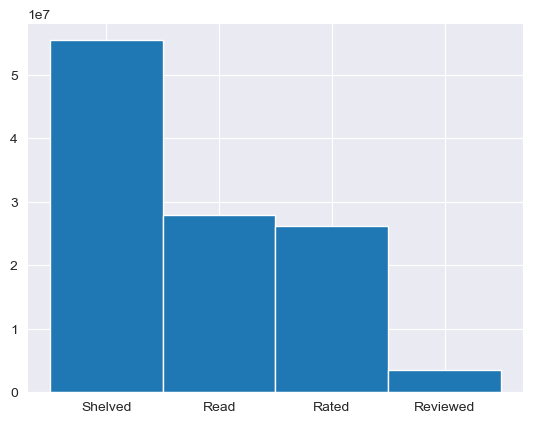

In [27]:
plt.bar(interaction_type.keys(), interaction_type.values(), width=1)

The distribution of interactions appears to follow a logical progression. Shelving a book, by marking it as "To Read" or "Maybe Later," is far more common than reading a book. The number of users rating a book is similar to the number of users marking it as read. Of those users, only a small subset take the time to write reviews. 

We are primarily interested in books which received user ratings. Using "Shelved" as a metric becomes problematic when accounting for shelves such as "DNF (Did Not Finish)" or "Worst Book I Ever Read." The latter category would be on-brand for this application, but is sadly out of scope.

In [28]:
# The is_read and review_text_incomplete columns are no longer necessary
rating_list.drop(columns=['is_read', 'is_reviewed'], inplace=True)
# The remaining analysis focuses exclusively on user ratings.
rating_list = rating_list[(rating_list['rating'] > 0)].reset_index(drop=True)
# From the original 17GB JSON we're left with a 460MB dataframe. 
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26193771 entries, 0 to 26193770
Data columns (total 4 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   book_id       category
 2   rating        category
 3   date_updated  string  
dtypes: category(3), string(1)
memory usage: 456.6 MB


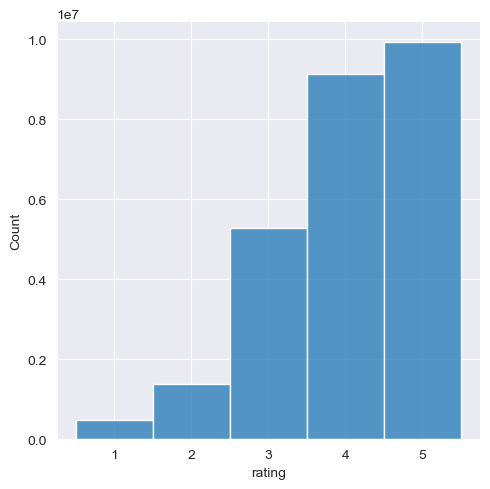

In [29]:
sns.displot(rating_list, x='rating', discrete=True)

In [30]:
# Over 70% of the ratings resulted in a positive score.
# Fewer than 7.5% of ratings came from users who did not enjoy a book.
rating_list['rating'].value_counts() / len(rating_list)

rating
5    0.378987
4    0.348261
3    0.201230
2    0.052664
1    0.018859
0    0.000000
Name: count, dtype: float64

In [31]:
# Time to pivot the data, and examine basic user statistics.
user_df = (rating_list['user_id']
           .value_counts()
           .reset_index()
           .sort_values(by='count', ascending=False)
           .rename(columns={'count': 'Books', 'user_id': 'User'}))

# Since users_ids are stored as a categorical value, all users are currently present in the dataframe:
# even those who never rated a book.
user_df = user_df[(user_df['Books'] > 0)]
user_df.head()

,User,Books
0,313745,5038
1,283412,4099
2,71495,3697
3,274684,3680
4,126156,3423


In [32]:
# The top 5 users have read an impressive amount of books. 
# How does the rest of the userbase compare?
user_df.Books.describe() 

count    656621.000000
mean         39.891766
std          86.059439
min           1.000000
25%           4.000000
50%          13.000000
75%          39.000000
max        5038.000000
Name: Books, dtype: float64

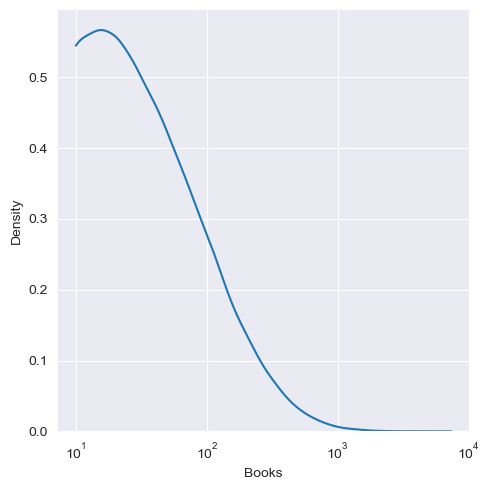

In [33]:
# The summary statistics indicate the distribution of books-rated per-user is heavily skewed.
sns.displot(user_df, x='Books', kind='kde', clip=[1,3248], log_scale=True, bw_adjust=1.2)

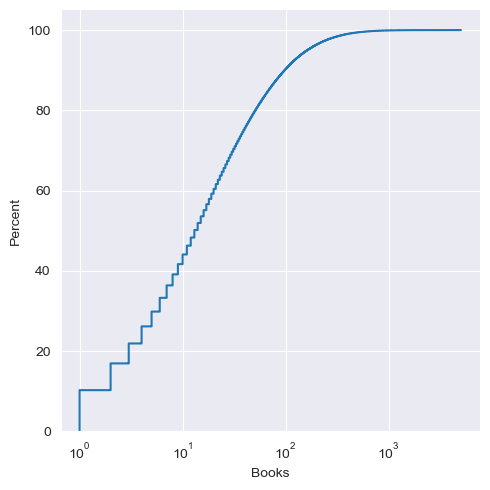

In [34]:
# What percent of users have read at least x books?
sns.displot(user_df, x='Books', kind='ecdf', stat='percent', log_scale=True)

In [35]:
thresholds = [.1, .2, .3, .4, .5, .6, .7, .8, .9]
user_df.Books.quantile(thresholds)

0.1     1.0
0.2     3.0
0.3     6.0
0.4     9.0
0.5    13.0
0.6    20.0
0.7    31.0
0.8    51.0
0.9    98.0
Name: Books, dtype: float64

At least 10% of the users for which we have data have only rated a single book. Between 40 and 50% of the users have rated fewer than 10.  
Reading 98 or more books puts a user in the top 10% of the population, but we know from our initial examination that the most active user has rated over 5,000 books. The range of ratings in the top 10% is several orders of magnitude larger than the rest of the population.

In [36]:
# Zooming in on the Top 10%
five_nines = [.9, .99, .999, .9999, .99999]
user_df.Books.quantile(five_nines)

0.90000      98.0000
0.99000     394.0000
0.99900     961.3800
0.99990    1857.0140
0.99999    3285.4704
Name: Books, dtype: float64

In [37]:
# Examining basic per-book statistics.

book_df = rating_list
book_df['rating'] = book_df['rating'].astype('int8') 
book_df = (book_df.groupby('book_id', observed=True)['rating']
           .agg(['count', 'mean'])
           .sort_values(by='count', ascending=False)
           .rename(columns={'count': 'N Users', 'mean': 'Average Rating'})
           .reset_index())
book_df.head()

,book_id,N Users,Average Rating
0,3,281135,4.503918
1,41865,230084,3.356379
2,15881,171459,4.394730
3,6,166185,4.547546
4,136251,164064,4.626067


In [38]:
book_df[['N Users', 'Average Rating']].describe()

,N Users,Average Rating
count,257001.000000,257001.000000
mean,101.920891,3.887049
std,1508.935472,0.600189
min,1.000000,1.000000
25%,3.000000,3.571429
50%,9.000000,4.000000
75%,27.000000,4.250000
max,281135.000000,5.000000


The average book in the source dataset has been read by 102 users, with an average rating of 3.8 on the Goodreads scale.

Over half the listed books were rated by fewer than 10 users. The per-book data initially appears to follow a similar distribution to the per-user table.

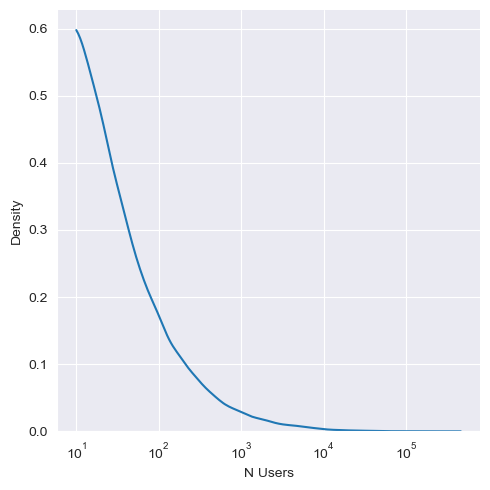

In [39]:
# It doesn't, but the distribution is still vaguely long-tailed.
sns.displot(book_df, x='N Users', kind='kde', clip=[1,160_000], log_scale=True, bw_adjust=1.2)

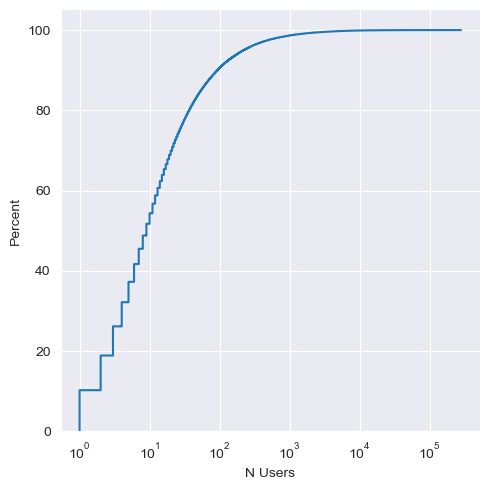

In [40]:
sns.displot(book_df, x='N Users', kind='ecdf', stat='percent', log_scale=True)

In [41]:
book_df['N Users'].quantile(thresholds)

0.1     1.0
0.2     3.0
0.3     4.0
0.4     6.0
0.5     9.0
0.6    13.0
0.7    21.0
0.8    37.0
0.9    93.0
Name: N Users, dtype: float64

In [42]:
book_df['N Users'].quantile(five_nines)

0.90000        93.00
0.99000      1403.00
0.99900     10866.00
0.99990     51433.70
0.99999    168452.82
Name: N Users, dtype: float64

## Putting It All Together

### Combining Authors and Books

In [43]:
n_books = book_list.shape[0]
book_list = book_list.merge(author_list, how='left')
assert book_list.shape[0] == n_books
del author_list
book_list.author_name.head()

0     Barbara Hambly
1     Rachel Roberts
2     Carolyn Haines
3         L.J. Smith
4    Carrie Ann Ryan
Name: author_name, dtype: string

### Combining Books and Works

In [44]:
# Start by comparing the total number of works and books in the dataset
print(f"Total work_id(s): {work_list.shape[0]:,}")
print(f"Total book_id(s): {book_list.shape[0]:>9,}\n")

# Double check that each book has a work_id, and count the number of unique work_id(s)
fantasy_work_ids = book_list['work_id'].unique()
print(f"Total fantasy works:  {book_list['work_id'].count():,}")
print(f"Unique fantasy works: {len(fantasy_work_ids):,}")

Total work_id(s): 1,521,962
Total book_id(s):   258,583

Total fantasy works:  258,583
Unique fantasy works: 122,022


In [45]:
# Remove works which don't appear in the book list
work_list = work_list[work_list['work_id'].isin(fantasy_work_ids)]
work_list.shape[0]

122022

In [46]:
# Unfortunately, the source data is incomplete for our purposes.
# The best example for many of the books on the fantasy booklist is not on the list itself.
works_not_present = book_list[~book_list.work_id.isin(work_list.work_id)].shape[0]
books_not_present = work_list[~work_list.book_id.isin(book_list.book_id)].shape[0]
print(f"Missing {works_not_present} work ids present in the book table.")
print(f"Missing {books_not_present} book ids present in the work table.")

Missing 0 work ids present in the book table.
Missing 5260 book ids present in the work table.


:::{note}
Now, you might recall the description of the dataset in the Goodreads Book Graph section. It mentioned that the complete dataset was also available, not just the Fantasy & Paranormal subset we've been examining so far. Why not grab the missing book_ids from that file?

...They're not there either. This project is using enough of your hard drive already: It seemed cruel to download it, process it, and check it when I could just tell you and move on.
::: 

In [47]:
# There are still more than enough books to work with. We ignore works with missing metadata.
work_list = work_list.merge(book_list, how='inner', on=['book_id', 'work_id'])
del book_list
work_list.isna().sum()

work_id           0
book_id           0
ratings_count     0
ratings_sum       0
average_rating    0
title             0
url               0
image_url         0
link              0
author_id         0
author_name       0
dtype: int64

### Combining Works and Ratings

In [49]:
# On Goodreads' rating scale, scores of 3+ are considered positive.
# We would prefer to recommend books our users will like, so we eliminate
# the poor ratings.
rating_list = rating_list[(rating_list['rating'] >= 3)].reset_index(drop=True)
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24320334 entries, 0 to 24320333
Data columns (total 4 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   book_id       category
 2   rating        int8    
 3   date_updated  string  
dtypes: category(2), int8(1), string(1)
memory usage: 426.2 MB


In [51]:
# Replace all the book_ids with the corresponding work_id
work_id_mapping = work_list[['book_id', 'work_id']].astype('Int64')
rating_list = rating_list.merge(work_id_mapping, how='left')
rating_list.drop(columns='book_id', inplace=True)
rating_list.isna().sum()

user_id               0
rating                0
date_updated          0
work_id         3276761
dtype: int64

In [53]:
# Remove any records that don't have a work_id
rating_list = rating_list[~(rating_list.work_id.isna())]
# Remove any duplicate user/work interactions
rating_list = rating_list.drop_duplicates(subset=['user_id', 'work_id'])
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21043573 entries, 2 to 24320333
Data columns (total 4 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   rating        int8    
 2   date_updated  string  
 3   work_id       Int64   
dtypes: Int64(1), category(1), int8(1), string(1)
memory usage: 623.7 MB


In [54]:
# Filter the ratings to include only the top 20% most-read books.
book_view = rating_list['work_id'].value_counts().reset_index().sort_values(by='count')
top_20_books = book_view['count'].quantile(.8) 
book_view = book_view[(book_view['count'] > top_20_books)]
rating_list = rating_list[rating_list['work_id'].isin(book_view['work_id'])]
del book_view
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19602036 entries, 2 to 24320333
Data columns (total 4 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   rating        int8    
 2   date_updated  string  
 3   work_id       Int64   
dtypes: Int64(1), category(1), int8(1), string(1)
memory usage: 582.5 MB


In [55]:
# Repeat the process for users, keeping only the 20% most active.
user_view = rating_list['user_id'].value_counts().reset_index().sort_values(by='count')
top_20_users = user_view['count'].quantile(.8)
user_view = user_view[(user_view['count'] > top_20_users)]
rating_list = rating_list[rating_list['user_id'].isin(user_view['user_id'])].reset_index(drop=True)
del user_view
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849506 entries, 0 to 14849505
Data columns (total 4 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       category
 1   rating        int8    
 2   date_updated  string  
 3   work_id       Int64   
dtypes: Int64(1), category(1), int8(1), string(1)
memory usage: 333.2 MB


In [56]:
# Remove any work_id(s) we no longer need after filtering the ratings
work_list = work_list[work_list['work_id'].isin(rating_list['work_id'])].reset_index(drop=True)
work_list.shape[0]

22997

Our almost (but not quite) finished data product contains 14.8 million ratings for just under 23,000 books. Two bits of housekeeping remain before wrapping up.

## Finishing Touches

### Creating a Work Index

In [57]:
# Just like usernames, we will eventually map works to integers between 1 and N
# Unlike usernames, we do care about the mapping between these numbers and the
# corresponding works.

# Sort by rating count. Wrecksys is a web app, and will store it's limited metadata in a database. 
# Basing the index on the number of ratings will simplify displaying titles in decreasing order of popularity.
work_list = work_list.sort_values(by=['ratings_sum', 'ratings_count'], ascending=False).reset_index(drop=True)
work_list['work_index'] = work_list.index + 1

# Create another map, and replace the work_ids in the ratings table with the new work_index
index_mapping = work_list[['work_id', 'work_index']]
rating_list = rating_list.merge(index_mapping, how='left').drop(columns='work_id').rename(columns={'work_index': 'work_id'})
rating_list.head()

,user_id,rating,date_updated,work_id
0,6,4,Wed Jul 27 09:41:36 -0700 2016,18407
1,6,5,Thu Sep 03 08:49:03 -0700 2015,22064
2,6,3,Mon Feb 06 20:34:45 -0800 2017,4458
3,6,3,Thu Feb 02 20:22:22 -0800 2017,2172
4,6,3,Sun Dec 06 12:11:41 -0800 2015,11380


### Save and Export Works

In [58]:
database_file = CONFIG.data.paths.database
ratings_file = CONFIG.data.paths.ratings
works_file = CONFIG.data.paths.books

# Save the total number of books for use in the TensorFlow model
model_config = CONFIG.data.model
model_config['vocabulary_size'] = work_list.shape[0] 
CONFIG.save()

# Save the cleaned works data to comply with Capstone requirements. 
# It's never used again, so feel free to delete it.
works_file.parent.mkdir(exist_ok=True)
work_list.to_feather(works_file)

# Create a simple database for the book metadata
con = sqlite3.connect(database_file)
work_list.to_sql('books', con, index=False, if_exists='replace')
con.close()

del work_list

### Create Rating Timestamps

In [59]:
# Convert date strings to UNIX timestamps
date_format = "%a %b %d %H:%M:%S %z %Y"
rating_list['date_updated'] = (pd.to_datetime(rating_list['date_updated'], format=date_format, utc=True)
                           - pd.Timestamp("1970-01-01", tz='UTC')) // pd.Timedelta("1s")

### Save Ratings

In [0]:
# Sort by user_id, then by timestamp to speed up the Tensorflow data pipeline.
# We could just as easily do this later, but since it's already loaded...
rating_list = rating_list.rename(columns={'date_updated': 'timestamp'}).sort_values(by=['user_id', 'timestamp'])

In [62]:
# Convert rating to a float, now that we're just about done.
rating_list = rating_list.astype({'user_id': 'int64', 'work_id': 'int64', 'rating': 'float32'}).reset_index(drop=True)
rating_list.head()

,user_id,rating,timestamp,work_id
0,6,5.0,1359914868,13262
1,6,4.0,1359939204,3252
2,6,5.0,1359939995,4047
3,6,4.0,1359940272,7070
4,6,5.0,1359940294,19180


In [63]:
# One last sanity check
rating_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849506 entries, 0 to 14849505
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   user_id    int64  
 1   rating     float32
 2   timestamp  int64  
 3   work_id    int64  
dtypes: float32(1), int64(3)
memory usage: 396.5 MB


In [64]:
# And that's all, folks!
ratings_file.parent.mkdir(exist_ok=True)
rating_list.to_feather(ratings_file)
del rating_list

In [65]:
# If you're satisfied with the presence of the source data, 
# and would like your disk space back before the next chapter:
def cleanup(file_manager):
    for k in file_manager.keys():
        file_manager[k].delete()

# Uncomment the line below.
# cleanup(fm) 